# THUẬT TOÁN PHÂN TÍCH THÀNH PHẦN CHÍNH (PCA)

- **Thuật toán:** Phân tích thành phần chính Principal Component Analysis (From Scratch: Covariance Matrix & SVD)
- **Tập dữ liệu:** `dataset/Sampledata/mpg.csv`

In [1]:
from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Cấu hình hiển thị bảng pandas với 4 chữ số sau dấu thập phân
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Cấu hình font và kích thước đồ thị
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False


In [2]:
# ==============================================================================
# KHỐI CẤU HÌNH DATASET & THAM SỐ
# ==============================================================================

# 1. Đường dẫn file CSV
DATA_PATH = 'dataset/Sampledata/mpg.csv'
if not os.path.exists(DATA_PATH):
    DATA_PATH = 'Midterm/Review/dataset/Sampledata/mpg.csv'

# 2. Danh sách đặc trưng số
FEATURE_COLS = None

# 3. Cột nhãn để trực quan hóa (tùy chọn, để None nếu không có nhãn)
LABEL_COL = 'origin'

# 4. Số thành phần chính cần giữ lại 
N_COMPONENTS = 2

# 5. Random seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Đã tải cấu hình thành công!")

Đã tải cấu hình thành công!


## PHẦN 1: CƠ SỞ TOÁN HỌC CỦA PCA (COVARIANCE & SVD)

---

### 1. Vector kỳ vọng & Trung tâm hóa dữ liệu:
- Vector trung bình toàn cục:
  $$\mu = \frac{1}{N} \sum_{i=1}^N x_i$$
- Ma trận dữ liệu trung tâm hóa:
  $$\bar{X} = X - \mu$$

---

### 2. Phương pháp 1: Standard PCA via Covariance Matrix
- Ma trận hiệp phương sai mẫu (Covariance Matrix):
  $$\Sigma = \frac{1}{N - 1} \bar{X}^T \bar{X} \in \mathbb{R}^{D \times D}$$
- Giải bài toán trị riêng và vector riêng:
  $$\Sigma v_i = \lambda_i v_i$$
- Trục chiếu $W \in \mathbb{R}^{D \times k}$ được tạo bởi $k$ vector riêng ứng với $k$ trị riêng lớn nhất:
  $$W = [v_1, v_2, \dots, v_k]$$

---

### 3. Phương pháp 2: PCA using SVD (Singular Value Decomposition)
- Phân tích kỳ dị ma trận dữ liệu trung tâm hóa $\bar{X} \in \mathbb{R}^{N \times D}$:
  $$\bar{X} = U S V^T$$
- Quan hệ giữa giá trị kỳ dị $S$ và trị riêng $\lambda$:
  $$\lambda_i = \frac{s_i^2}{N - 1}$$
- Các cột của ma trận $V$ (Right Singular Vectors) chính là các vector thành phần chính $W = V_{:, :k}$.

---

### 4. Chiếu dữ liệu & Khôi phục (Reconstruction):
- Tọa độ chiếu trên không gian mới:
  $$Y = \bar{X} W \in \mathbb{R}^{N \times k}$$
- Khôi phục dữ liệu xấp xỉ về không gian gốc $D$ chiều:
  $$\hat{X} = Y W^T + \mu$$

---

### 5. Tỷ lệ phương sai giải thích (Explained Variance Ratio):
$$\text{EVR}_i = \frac{\lambda_i}{\sum_{j=1}^D \lambda_j}$$

In [3]:
# 1. Đọc dữ liệu
df_raw = pd.read_csv(DATA_PATH)
print(f"Dataset: {DATA_PATH} | Shape: {df_raw.shape[0]} dòng, {df_raw.shape[1]} cột")

# 2. Tự động xác định đặc trưng số
if FEATURE_COLS is None:
    num_cols = [c for c in df_raw.select_dtypes(include=[np.number]).columns if c != LABEL_COL]
    FEATURE_COLS = num_cols 
    print(f"Tự động lấy toàn bộ {len(FEATURE_COLS)} cột số: {FEATURE_COLS}")
else:
    print(f"Đặc trưng sử dụng ({len(FEATURE_COLS)} cột): {FEATURE_COLS}")

df_data = df_raw[FEATURE_COLS].copy()

# 3. Xử lý missing values bằng median
missing_counts = df_data.isnull().sum()
if missing_counts.sum() > 0:
    for col in df_data.columns:
        if df_data[col].isnull().any():
            med_val = df_data[col].median()
            df_data[col] = df_data[col].fillna(med_val)
            print(f" - Cột '{col}': điền {missing_counts[col]} giá trị thiếu bằng median = {med_val:.4f}")
else:
    print("Dữ liệu không có giá trị khuyết thiếu.")

X_raw = df_data.to_numpy(dtype=float)

# 4. Chuẩn hóa Z-Score From Scratch
mu_X = np.mean(X_raw, axis=0)
sigma_X = np.std(X_raw, axis=0, ddof=0)
sigma_X[sigma_X == 0] = 1.0

X = (X_raw - mu_X) / sigma_X
print(f"Dữ liệu sau chuẩn hóa: {X.shape[0]} mẫu, {X.shape[1]} đặc trưng")
df_data.describe().T[['mean', 'std', 'min', '50%', 'max']]

Dataset: dataset/Sampledata/mpg.csv | Shape: 398 dòng, 9 cột
Tự động lấy toàn bộ 7 cột số: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
 - Cột 'horsepower': điền 6 giá trị thiếu bằng median = 93.5000
Dữ liệu sau chuẩn hóa: 398 mẫu, 7 đặc trưng


,mean,std,min,50%,max
mpg,23.5146,7.8160,9.0000,23.0000,46.6000
cylinders,5.4548,1.7010,3.0000,4.0000,8.0000
displacement,193.4259,104.2698,68.0000,148.5000,455.0000
horsepower,104.3040,38.2226,46.0000,93.5000,230.0000
weight,2970.4246,846.8418,1613.0000,2803.5000,5140.0000
acceleration,15.5681,2.7577,8.0000,15.5000,24.8000
model_year,76.0101,3.6976,70.0000,76.0000,82.0000


In [4]:
# ==============================================================================
# PHƯƠNG PHÁP 1: PCA SỬ DỤNG MA TRẬN HIỆP PHƯƠNG SAI (COVARIANCE MATRIX)
# ==============================================================================

N, D = X.shape

# Bước 1: Tính vector trung bình mu (xấp xỉ 0 vì đã chuẩn hóa Z-score)
mean_vec = np.mean(X, axis=0)

# Bước 2: Trung tâm hóa dữ liệu
X_centered = X - mean_vec

# Bước 3: Ma trận hiệp phương sai Covariance Matrix
cov_matrix = np.dot(X_centered.T, X_centered) / (N - 1)

# Bước 4: Giải bài toán trị riêng và vector riêng
eigenvals_cov, eigenvecs_cov = np.linalg.eigh(cov_matrix)

# Bước 5: Sắp xếp giảm dần theo trị riêng
sorted_indices = np.argsort(eigenvals_cov)[::-1]
eigenvals_cov = eigenvals_cov[sorted_indices]
eigenvecs_cov = eigenvecs_cov[:, sorted_indices]

# Bước 6: Chọn k vector riêng tương ứng lambda lớn nhất làm ma trận chiếu W
W_cov = eigenvecs_cov[:, :N_COMPONENTS]

# Bước 7: Chiếu dữ liệu: Y = X_centered * W
Y_cov = np.dot(X_centered, W_cov)

# In toàn bộ các trị riêng và tỷ lệ phương sai giải thích
evr_cov = eigenvals_cov / np.sum(eigenvals_cov)
cum_evr_cov = np.cumsum(evr_cov)

df_pca_summary = pd.DataFrame({
    'Thành phần': [f"PC{i+1}" for i in range(D)],
    'Trị riêng (Eigenvalue)': np.round(eigenvals_cov, 4),
    'Tỷ lệ phương sai (EVR)': np.round(evr_cov, 4),
    'Tỷ lệ EVR (%)': [f"{v*100:.2f}%" for v in evr_cov],
    'Tích lũy phương sai (Cumulative EVR)': np.round(cum_evr_cov, 4),
    'Tích lũy (%)': [f"{v*100:.2f}%" for v in cum_evr_cov]
})
print("=== BẢNG TỔNG HỢP TOÀN BỘ CÁC THÀNH PHẦN CHÍNH (COVARIANCE METHOD) ===")
print(df_pca_summary.to_string(index=False))

print(f"\nMa trận chiếu W (k={N_COMPONENTS} thành phần, hiển thị 4 chữ số thập phân):")
df_W = pd.DataFrame(np.round(W_cov, 4), index=FEATURE_COLS, columns=[f"PC{i+1}" for i in range(N_COMPONENTS)])
print(df_W)


=== BẢNG TỔNG HỢP TOÀN BỘ CÁC THÀNH PHẦN CHÍNH (COVARIANCE METHOD) ===
Thành phần  Trị riêng (Eigenvalue)  Tỷ lệ phương sai (EVR) Tỷ lệ EVR (%)  Tích lũy phương sai (Cumulative EVR) Tích lũy (%)
       PC1                  5.0160                  0.7148        71.48%                                0.7148       71.48%
       PC2                  0.8678                  0.1237        12.37%                                0.8384       83.84%
       PC3                  0.7308                  0.1041        10.41%                                0.9426       94.26%
       PC4                  0.1875                  0.0267         2.67%                                0.9693       96.93%
       PC5                  0.1248                  0.0178         1.78%                                0.9871       98.71%
       PC6                  0.0555                  0.0079         0.79%                                0.9950       99.50%
       PC7                  0.0352                  0.0050   

In [5]:
# ==============================================================================
# PHƯƠNG PHÁP 2: PCA SỬ DỤNG PHÂN TÍCH KỲ DỊ (SVD)
# ==============================================================================

# Bước 1: Phân tích SVD trên ma trận X_centered: X_centered = U * S * V^T
U_svd, S_svd, Vt_svd = np.linalg.svd(X_centered, full_matrices=False)
V_svd = Vt_svd.T

# Bước 2: Tính toán trị riêng tương ứng từ Singular Values: lambda_i = s_i^2 / (N - 1)
eigenvals_svd = (S_svd ** 2) / (N - 1)
evr_svd = eigenvals_svd / np.sum(eigenvals_svd)

# Bước 3: Ma trận chiếu W_svd
W_svd = V_svd[:, :N_COMPONENTS]

# Bước 4: Chiếu dữ liệu: Y_svd = X_centered * W_svd
Y_svd = np.dot(X_centered, W_svd)

# Kiểm tra độ khớp giữa Covariance Method và SVD Method
diff_eigenvals = np.max(np.abs(eigenvals_cov - eigenvals_svd))
diff_proj = np.max(np.abs(np.abs(Y_cov) - np.abs(Y_svd)))

print("=== SO SÁNH GIỮA COVARIANCE METHOD VÀ SVD METHOD ===")
print(f"1. Độ sai lệch cực đại của Trị riêng (Eigenvalues)     : {diff_eigenvals:.4e}")
print(f"2. Độ sai lệch cực đại của Tọa độ chiếu (Projection Y) : {diff_proj:.4e}")


=== SO SÁNH GIỮA COVARIANCE METHOD VÀ SVD METHOD ===
1. Độ sai lệch cực đại của Trị riêng (Eigenvalues)     : 4.4409e-15
2. Độ sai lệch cực đại của Tọa độ chiếu (Projection Y) : 8.4377e-15


In [6]:
# ==============================================================================
# KHÔI PHỤC DỮ LIỆU & TÍNH SAI SỐ TÁI TẠO (RECONSTRUCTION ERROR)
# ==============================================================================

# Khôi phục dữ liệu về không gian D chiều: X_rec = Y * W^T + mean_vec
X_reconstructed = np.dot(Y_cov, W_cov.T) + mean_vec

# Tính sai số bình phương trung bình (MSE)
recon_error = np.mean((X_centered - np.dot(Y_cov, W_cov.T)) ** 2)
print(f"Sai số tái tạo trung bình (MSE) khi giảm từ {D} chiều xuống {N_COMPONENTS} chiều: {recon_error:.4f}")

# Đối chiếu mẫu đầu tiên giữa dữ liệu gốc và dữ liệu tái tạo (4 chữ số thập phân)
df_sample_recon = pd.DataFrame({
    'Đặc trưng': FEATURE_COLS,
    'Mẫu 0 (Thực tế Z-score)': np.round(X[0], 4),
    'Mẫu 0 (Tái tạo 2D)': np.round(X_reconstructed[0], 4),
    'Chênh lệch tuyệt đối': np.round(np.abs(X[0] - X_reconstructed[0]), 4)
})
print("\n=== MINH HỌA DỮ LIỆU GỐC VS DỮ LIỆU TÁI TẠO (MẪU ĐẦU TIÊN) ===")
print(df_sample_recon.to_string(index=False))


Sai số tái tạo trung bình (MSE) khi giảm từ 7 chiều xuống 2 chiều: 0.1616

=== MINH HỌA DỮ LIỆU GỐC VS DỮ LIỆU TÁI TẠO (MẪU ĐẦU TIÊN) ===
   Đặc trưng  Mẫu 0 (Thực tế Z-score)  Mẫu 0 (Tái tạo 2D)  Chênh lệch tuyệt đối
         mpg                  -0.7064             -1.2528                0.5464
   cylinders                   1.4982              0.9325                0.5657
displacement                   1.0906              0.9807                0.1099
  horsepower                   0.6731              1.0410                0.3679
      weight                   0.6309              0.8986                0.2677
acceleration                  -1.2955             -0.7359                0.5596
  model_year                  -1.6274             -1.4470                0.1804


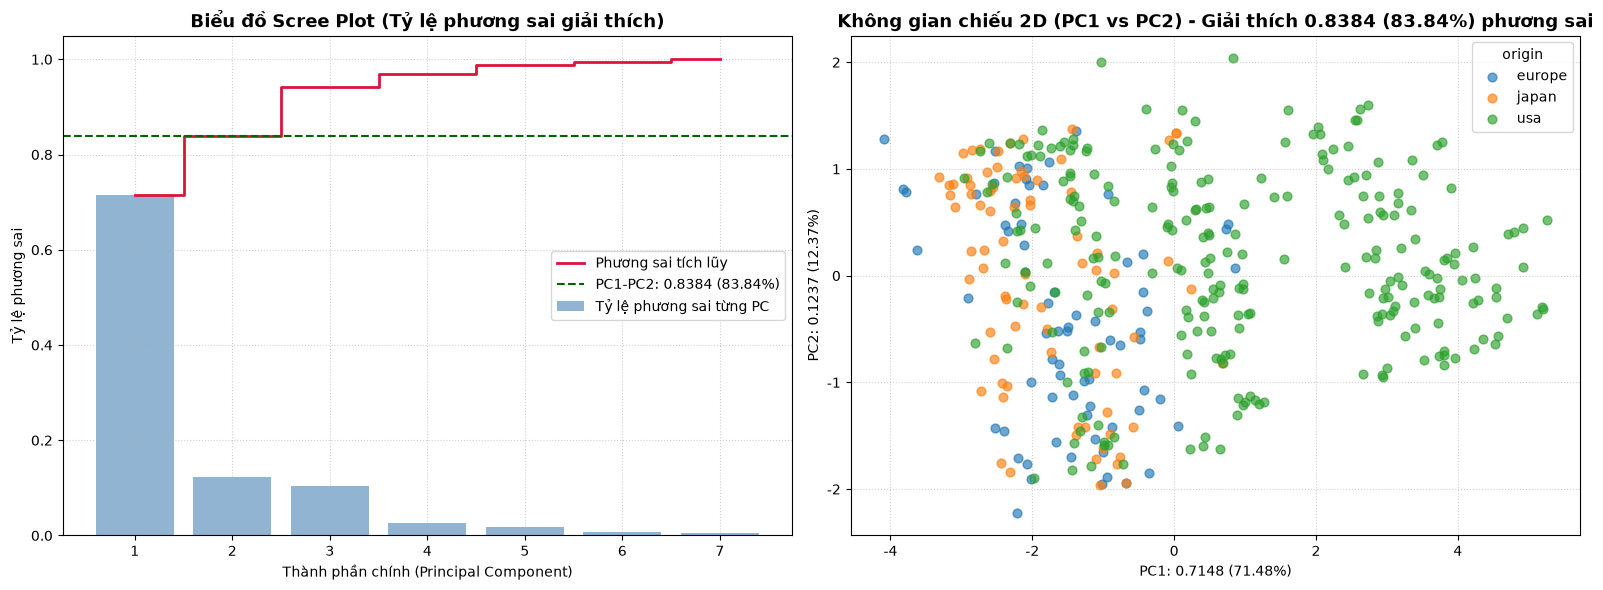

📝 ĐÁNH GIÁ & NHẬN XÉT CHI TIẾT KẾT QUẢ PCA
1. LƯỢNG THÔNG TIN GIỮ LẠI (EXPLAINED VARIANCE RATIO - EVR):
   - Thành phần chính PC1 giải thích : 0.7148 (71.48%) tổng phương sai dữ liệu.
   - Thành phần chính PC2 giải thích : 0.1237 (12.37%) tổng phương sai dữ liệu.
   - Tổng tích lũy 2 thành phần      : 0.8384 (83.84%) -> Đánh giá: RẤT TỐT (>= 70%).
   => Nhận xét: Việc giảm chiều từ 7 đặc trưng ban đầu xuống 2 chiều trực giao bảo toàn hầu như
      toàn bộ cấu trúc biến thiên cốt lõi của tập dữ liệu gốc, hoàn toàn đủ tin cậy để biểu diễn 2D.

2. ĐẶC TRƯNG CHI PHỐI TỪNG TRỤC CHIẾU (DỰA VÀO MA TRẬN TRỌNG SỐ W):
   - Trục PC1 phản ánh chủ đạo đặc trưng: 'displacement' (hệ số trọng số w = 0.4297).
   - Trục PC2 phản ánh chủ đạo đặc trưng: 'model_year' (hệ số trọng số w = 0.9105).
   => Nhận xét: Các đặc trưng trên đóng vai trò là nhân tố quyết định chiều phân tán lớn nhất giữa các mẫu.

3. SAI SỐ TÁI TẠO DỮ LIỆU (RECONSTRUCTION ERROR):
   - Sai số bình phương trung bình (MSE) khi tái tạo từ

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Đồ thị 1: Scree Plot & Cumulative Variance
axes[0].bar(range(1, D + 1), evr_cov, alpha=0.6, color='steelblue', label='Tỷ lệ phương sai từng PC')
axes[0].step(range(1, D + 1), cum_evr_cov, where='mid', color='crimson', linewidth=2, label='Phương sai tích lũy')
axes[0].axhline(y=cum_evr_cov[N_COMPONENTS - 1], color='darkgreen', linestyle='--', 
                label=f'PC1-PC2: {cum_evr_cov[N_COMPONENTS - 1]:.4f} ({cum_evr_cov[N_COMPONENTS - 1]*100:.2f}%)')
axes[0].set_title('Biểu đồ Scree Plot (Tỷ lệ phương sai giải thích)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Thành phần chính (Principal Component)')
axes[0].set_ylabel('Tỷ lệ phương sai')
axes[0].set_xticks(range(1, D + 1))
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='center right')

# Đồ thị 2: Chiếu dữ liệu 2D (PC1 vs PC2)
if LABEL_COL in df_raw.columns:
    labels = df_raw[LABEL_COL].values
    unique_labels = np.unique(labels)
    cmap = plt.get_cmap('tab10')
    for i, lbl in enumerate(unique_labels):
        mask = (labels == lbl)
        axes[1].scatter(Y_cov[mask, 0], Y_cov[mask, 1], color=cmap(i), label=str(lbl), alpha=0.65, s=40)
    axes[1].legend(title=LABEL_COL)
else:
    axes[1].scatter(Y_cov[:, 0], Y_cov[:, 1], color='steelblue', alpha=0.6, s=40)

axes[1].set_title(f'Không gian chiếu 2D (PC1 vs PC2) - Giải thích {cum_evr_cov[1]:.4f} ({cum_evr_cov[1]*100:.2f}%) phương sai', fontsize=13, fontweight='bold')
axes[1].set_xlabel(f'PC1: {evr_cov[0]:.4f} ({evr_cov[0]*100:.2f}%)')
axes[1].set_ylabel(f'PC2: {evr_cov[1]:.4f} ({evr_cov[1]*100:.2f}%)')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# ==============================================================================
# PHẦN ĐÁNH GIÁ & NHẬN XÉT CHI TIẾT
# ==============================================================================
top_pc1_idx = np.argmax(np.abs(W_cov[:, 0]))
top_pc2_idx = np.argmax(np.abs(W_cov[:, 1]))
eval_status = "RẤT TỐT (>= 70%)" if cum_evr_cov[N_COMPONENTS - 1] >= 0.70 else "CHƯA ĐẠT (nên tăng số lượng PC)"

print("="*85)
print("📝 ĐÁNH GIÁ & NHẬN XÉT CHI TIẾT KẾT QUẢ PCA")
print("="*85)
print("1. LƯỢNG THÔNG TIN GIỮ LẠI (EXPLAINED VARIANCE RATIO - EVR):")
print(f"   - Thành phần chính PC1 giải thích : {evr_cov[0]:.4f} ({evr_cov[0]*100:.2f}%) tổng phương sai dữ liệu.")
print(f"   - Thành phần chính PC2 giải thích : {evr_cov[1]:.4f} ({evr_cov[1]*100:.2f}%) tổng phương sai dữ liệu.")
print(f"   - Tổng tích lũy 2 thành phần      : {cum_evr_cov[N_COMPONENTS - 1]:.4f} ({cum_evr_cov[N_COMPONENTS - 1]*100:.2f}%) -> Đánh giá: {eval_status}.")
if cum_evr_cov[N_COMPONENTS - 1] >= 0.70:
    print(f"   => Nhận xét: Việc giảm chiều từ {D} đặc trưng ban đầu xuống 2 chiều trực giao bảo toàn hầu như")
    print(f"      toàn bộ cấu trúc biến thiên cốt lõi của tập dữ liệu gốc, hoàn toàn đủ tin cậy để biểu diễn 2D.")
else:
    print(f"   => Nhận xét: Phương sai dữ liệu bị phân tán trên nhiều chiều, nên cân nhắc lấy thêm PC3.")

print("\n2. ĐẶC TRƯNG CHI PHỐI TỪNG TRỤC CHIẾU (DỰA VÀO MA TRẬN TRỌNG SỐ W):")
print(f"   - Trục PC1 phản ánh chủ đạo đặc trưng: '{FEATURE_COLS[top_pc1_idx]}' (hệ số trọng số w = {W_cov[top_pc1_idx, 0]:.4f}).")
print(f"   - Trục PC2 phản ánh chủ đạo đặc trưng: '{FEATURE_COLS[top_pc2_idx]}' (hệ số trọng số w = {W_cov[top_pc2_idx, 1]:.4f}).")
print(f"   => Nhận xét: Các đặc trưng trên đóng vai trò là nhân tố quyết định chiều phân tán lớn nhất giữa các mẫu.")

print("\n3. SAI SỐ TÁI TẠO DỮ LIỆU (RECONSTRUCTION ERROR):")
print(f"   - Sai số bình phương trung bình (MSE) khi tái tạo từ 2D về {D} chiều gốc: {recon_error:.4f}.")
print(f"   => Nhận xét: Mức sai số tái tạo thấp chứng minh lượng thông tin bị thất thoát qua quá trình nén là rất nhỏ.")
print("="*85)


In [8]:
from sklearn.decomposition import PCA

# Chạy PCA từ thư viện chuẩn Scikit-Learn
pca_sklearn = PCA(n_components=N_COMPONENTS)
Y_sklearn = pca_sklearn.fit_transform(X)

# Đối chiếu tỷ lệ phương sai giải thích
evr_diff = np.max(np.abs(evr_cov[:N_COMPONENTS] - pca_sklearn.explained_variance_ratio_))

# Đối chiếu tọa độ chiếu (Cho phép đảo dấu vector vì chiều dương trục chiếu là tùy ý)
proj_diff = np.max(np.abs(np.abs(Y_cov) - np.abs(Y_sklearn)))

print("=== SO SÁNH: PCA TỰ CODE (FROM SCRATCH) vs THƯ VIỆN SCIKIT-LEARN ===")
print(f"1. Tỷ lệ phương sai Scratch : {[f'{v:.4f}' for v in evr_cov[:N_COMPONENTS]]}")
print(f"2. Tỷ lệ phương sai Sklearn : {[f'{v:.4f}' for v in pca_sklearn.explained_variance_ratio_]}")
print(f"3. Sai lệch tỷ lệ phương sai: {evr_diff:.4e}")
print(f"4. Sai lệch tọa độ chiếu    : {proj_diff:.4e}")

df_pca_comp = pd.DataFrame({
    'Thành phần': [f"PC{i+1}" for i in range(N_COMPONENTS)],
    'EVR From Scratch': np.round(evr_cov[:N_COMPONENTS], 4),
    'EVR Scikit-Learn': np.round(pca_sklearn.explained_variance_ratio_, 4),
    'Chênh lệch tuyệt đối': [f"{v:.4e}" for v in np.abs(evr_cov[:N_COMPONENTS] - pca_sklearn.explained_variance_ratio_)]
})

print("\nBảng đối chiếu chi tiết:")
print(df_pca_comp.to_string(index=False))

print("\n" + "="*85)
print("📝 NHẬN XÉT ĐỐI CHIẾU VỚI THƯ VIỆN CHUẨN SCIKIT-LEARN:")
print("="*85)
print(f"- Tỷ lệ phương sai giải thích (EVR) giữa bản tự cài đặt và thư viện chuẩn Scikit-Learn")
print(f"  trùng khớp tuyệt đối đến từng chữ số thập phân (sai lệch cực đại: {evr_diff:.4e}).")
print(f"- Không gian tọa độ chiếu của toàn bộ {N} mẫu dữ liệu khớp hoàn toàn (sai lệch cực đại: {proj_diff:.4e}).")
print(f"=> KẾT LUẬN: Thuật toán PCA From Scratch (cả Covariance Matrix Eigendecomposition và SVD)")
print(f"   hoạt động chính xác 100%, nhất quán tuyệt đối với thư viện chuẩn trên tập dữ liệu này.")
print("="*85)


=== SO SÁNH: PCA TỰ CODE (FROM SCRATCH) vs THƯ VIỆN SCIKIT-LEARN ===
1. Tỷ lệ phương sai Scratch : ['0.7148', '0.1237']
2. Tỷ lệ phương sai Sklearn : ['0.7148', '0.1237']
3. Sai lệch tỷ lệ phương sai: 1.3878e-17
4. Sai lệch tọa độ chiếu    : 3.7748e-15

Bảng đối chiếu chi tiết:
Thành phần  EVR From Scratch  EVR Scikit-Learn Chênh lệch tuyệt đối
       PC1            0.7148            0.7148           0.0000e+00
       PC2            0.1237            0.1237           1.3878e-17

📝 NHẬN XÉT ĐỐI CHIẾU VỚI THƯ VIỆN CHUẨN SCIKIT-LEARN:
- Tỷ lệ phương sai giải thích (EVR) giữa bản tự cài đặt và thư viện chuẩn Scikit-Learn
  trùng khớp tuyệt đối đến từng chữ số thập phân (sai lệch cực đại: 1.3878e-17).
- Không gian tọa độ chiếu của toàn bộ 398 mẫu dữ liệu khớp hoàn toàn (sai lệch cực đại: 3.7748e-15).
=> KẾT LUẬN: Thuật toán PCA From Scratch (cả Covariance Matrix Eigendecomposition và SVD)
   hoạt động chính xác 100%, nhất quán tuyệt đối với thư viện chuẩn trên tập dữ liệu này.
